In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
import keras_tuner as kt
from keras import layers, Sequential, Input
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping
from keras.losses import MeanSquaredError
from keras.metrics import RootMeanSquaredError
from keras.layers import LSTM, Dropout, Dense

2026-04-09 07:52:16.670305: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775721137.070322      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775721137.181380      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775721138.212766      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775721138.212836      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775721138.212840      55 computation_placer.cc:177] computation placer alr

In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/andgiana/curah-hujan-bulanan/Dataset_Train_Bulanan.csv
/kaggle/input/datasets/andgiana/curah-hujan-bulanan/Dataset_Validation_Bulanan.csv
/kaggle/input/datasets/andgiana/curah-hujan-bulanan/Dataset_Testing_Bulanan.csv
/kaggle/input/datasets/andgiana/curah-hujan-gabungan-bulanan/Data Gabung Curah Hujan Bulanan.csv


In [3]:
path = "/kaggle/input/datasets/andgiana/curah-hujan-gabungan-bulanan"

curah_hujan= pd.read_csv(f"{path}/Data Gabung Curah Hujan Bulanan.csv")

# Normalisasi Data

In [4]:
fitur = ["curah_hujan", "kelembapan_udara", "kecepatan_angin", "suhu"]

In [5]:
total_data = len(curah_hujan)
window_size = 13
total_window = total_data - window_size

In [6]:
train_size = int(0.6 * total_window)
valid_size = int(0.2 * total_window)
test_size = total_window - train_size - valid_size

In [7]:
batas_train_size = train_size + window_size

In [8]:
scaler = MinMaxScaler()

scaler.fit(curah_hujan.iloc[:batas_train_size][fitur])
curah_hujan_scaled = scaler.transform(curah_hujan[fitur])

In [9]:
# Buat class DataWindow untuk training data di model lstm

class DataWindow():
    def __init__(
        self, raw_data, window_size, target_columns=0):
        self.raw_data = raw_data
        self.window_size = window_size
        self.target_columns = target_columns
        self.input, self.label = self.make_window(raw_data, window_size, target_columns)
        
    def make_window(self, data, window_size, target_col=0):
      X, y = [], []
      for i in range(len(data) - window_size):
          X.append(data[i:i + window_size, :])
          y.append(data[i + window_size, target_col])
      return np.array(X), np.array(y)
    
    # Buat grafik        
    def plot(
      self, model=None, plot_col=0, max_subplot=3
    ):
        inputs, labels = self.sample_batch
        plt.figure(figsize=(12, 8))
        max_n = min(max_subplot, len(inputs))
        for n in range (max_n):
            plt.subplot(max_n, 1, n + 1)
            plt.ylabel(f"Fitur index {plot_col}")
            
            # Plot input
            input_data = inputs[n, :, plot_col]
            time_steps = range(-self.window_size, 0)
            plt.plot(time_steps, input_data, label="Inputs", marker="o", zorder=-10)
            
            # Plot label
            plt.scatter(0, labels[n], s=64)
            
            # Plot prediksi model
            if model is not None:
                input_model = inputs[n : n + 1, :, :]
                prediksi = model.predict(input_model, verbose=0)
                plt.scatter(0, prediksi[0, 0], marker="x", s=64)
                
            if n == 0:
                plt.legend()
        
        plt.xlabel("Bulan ke-")
        plt.tight_layout()
        plt.show()
            
    @property
    def sample_batch(self):
        result = getattr(self, "_sample_batch", None)
        if result is None:
            batch_size = 32
            input = self.input[:batch_size]
            labels = self.label[:batch_size]
            result = (input, labels)
            self._sample_batch = result
        return result

#### Transformasi Data Time Series

In [10]:
curah_hujan_window = DataWindow(curah_hujan_scaled, window_size, target_columns=0)

X_all, y_all = curah_hujan_window.input, curah_hujan_window.label

X_train, y_train = X_all[:train_size], y_all[:train_size]
X_valid, y_valid = X_all[train_size : train_size + valid_size], y_all[train_size : train_size + valid_size]
X_test, y_test = X_all[train_size + valid_size:], y_all[train_size + valid_size:]

print(f"X_train = {X_train.shape}, y_train = {y_train.shape}")
print(f"X_valid = {X_valid.shape}, y_valid = {y_valid.shape}")
print(f"X_test = {X_test.shape}, y_test = {y_test.shape}")

X_train = (64, 13, 4), y_train = (64,)
X_valid = (21, 13, 4), y_valid = (21,)
X_test = (22, 13, 4), y_test = (22,)


#### Slicing data keperluan grafik

In [11]:
class WindowHelper(DataWindow):
    def __init__(self, X_data, y_data, window_size, target_columns=0):
        self.input = X_data
        self.label = y_data
        self.window_size = window_size
        self.target_columns = target_columns

In [12]:
train_window = WindowHelper(X_train, y_train, window_size)
valid_window = WindowHelper(X_valid, y_valid, window_size)
test_window = WindowHelper(X_test, y_test, window_size)

# Membangun Model LSTM

### Mendefinisikan model LSTM

#### Membuat fungsi pembangun model (biarkan komputer yang nebak)

In [13]:
class MyTunerModelHyperModel(kt.HyperModel):
    def build(self, hp):
        model = Sequential()
        model.add(Input(shape=(window_size, X_train.shape[-1])))
        
        # Menebak jumlah lstm layers yang dibutuhkan model
        n_lstm_layers = hp.Int("n_lstm_layers", min_value=1, max_value=3, default=2)
        for i in range(n_lstm_layers):
            n_neurons_lstm = hp.Choice(f"neurons_lstm_layers{i}", values=[128, 64, 32,16])
            is_return_sequences = True if i < n_lstm_layers - 1 else False
            model.add(LSTM(n_neurons_lstm, return_sequences=is_return_sequences, activation="tanh"))
            
            # Tambah dropout layer
            model.add(Dropout(hp.Float(f"neuron_dropout{i}", min_value=0.1, max_value=0.5, step=0.1)))
            
        # Menebak jumlah dense layers yang dibutuhkan model    
        n_dense_layers = hp.Int("n_dense_layers", min_value=1, max_value=3, default=2)
        for ii in range(n_dense_layers):
            n_neurons_dense = hp.Choice(f"neurons_dense_layers{ii}", values=[16, 32, 64, 128, 256])
            model.add(Dense(n_neurons_dense, activation="softplus"))
        model.add(Dense(1, activation="linear"))
        
        # Nebak learning rate
        learning_rate = hp.Float("learning_rate", min_value=1e-4, max_value=1e-2, sampling="log")
        
        # Compile model
        model.compile(loss=MeanSquaredError(),
                    optimizer=Adam(learning_rate=learning_rate),
                    metrics=[RootMeanSquaredError()]
        )
        
        return model
    
    def fit(self, hp, model, *args, **kwargs):
        # Tebak batch size
        hp_batch_size = hp.Choice("batch_size", values=[16, 32, 64])
        
        return model.fit(
            *args,
            batch_size=hp_batch_size,
            **kwargs
        )

In [14]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=50,
    mode="min",
    restore_best_weights=True
)

tf.keras.utils.set_random_seed(42)

In [15]:
hyperband_tuner = kt.Hyperband(
    MyTunerModelHyperModel(),
    objective="val_loss",
    max_epochs=500,
    factor=3,
    overwrite=True,
    directory="hasil_tuner_hyperband_softplus",
    project_name="model_lstm_softplus",
    seed=42        
)

I0000 00:00:1775721179.335326      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775721179.341137      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [16]:
hyperband_tuner.search(
    X_train, y_train,
    validation_data=(X_valid, y_valid),
    callbacks=[early_stopping]
)

best_hp = hyperband_tuner.get_best_hyperparameters(num_trials=1)[0]
print("HASIL TEBAKAN YANG TERBAIK BUAT HYPERPARAMETER")
print(f"Jumlah layer LSTM       : {best_hp.get('n_lstm_layers')}")
layer_lstm = best_hp.get("n_lstm_layers")
for i in range(layer_lstm):
    jumlah = best_hp.get(f"neurons_lstm_layers{i}")
    dropout = best_hp.get(f"neuron_dropout{i}")
    print(f"Layer LSTM ke-{i+1}, neuronnya: {jumlah}, dropoutnya: {dropout}")

print(f"Jumlah layer Dense      : {best_hp.get('n_dense_layers')}")
layer_dense = best_hp.get("n_dense_layers")
for ii in range(layer_dense):
    jumlah = best_hp.get(f"neurons_dense_layers{ii}")
    print(f"Layer Dense ke-{ii+1}, neuronnya: {jumlah}")

print(f"Learning rate           : {best_hp.get('learning_rate')}")
print(f"Batch size              : {best_hp.get('batch_size')}")

# Mengambil trial terbaik dari oracle Hyperband
best_trial = hyperband_tuner.oracle.get_best_trials(num_trials=1)[0]

# Mengambil jumlah epoch model
best_epoch = best_trial.best_step

print(f"Optimal Epoch: {best_epoch}")

Trial 725 Complete [00h 00m 30s]
val_loss: 0.01686711609363556

Best val_loss So Far: 0.00878202449530363
Total elapsed time: 02h 38m 52s
HASIL TEBAKAN YANG TERBAIK BUAT HYPERPARAMETER
Jumlah layer LSTM       : 2
Layer LSTM ke-1, neuronnya: 128, dropoutnya: 0.30000000000000004
Layer LSTM ke-2, neuronnya: 64, dropoutnya: 0.5
Jumlah layer Dense      : 2
Layer Dense ke-1, neuronnya: 64
Layer Dense ke-2, neuronnya: 16
Learning rate           : 0.0009887195863122636
Batch size              : 16
Optimal Epoch: 6


#### Buat model lstm

In [17]:
keras.backend.clear_session()

lstm_model = hyperband_tuner.hypermodel.build(best_hp)

lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 13, 128)        │        68,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,721 (479.38 KB)

 Trainable params: 122,721 (479.38 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
history = lstm_model.fit(
    X_train, y_train,
    batch_size=16,
    epochs=89,
    validation_data=(X_valid, y_valid),
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/89
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0276 - root_mean_squared_error: 0.1660 - val_loss: 0.0187 - val_root_mean_squared_error: 0.1367
Epoch 2/89
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0196 - root_mean_squared_error: 0.1397 - val_loss: 0.0192 - val_root_mean_squared_error: 0.1385
Epoch 3/89
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0218 - root_mean_squared_error: 0.1469 - val_loss: 0.0193 - val_root_mean_squared_error: 0.1388
Epoch 4/89
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0211 - root_mean_squared_error: 0.1449 - val_loss: 0.0190 - val_root_mean_squared_error: 0.1378
Epoch 5/89
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0216 - root_mean_squared_error: 0.1469 - val_loss: 0.0187 - val_root_mean_squared_error: 0.1368
Epoch 6/89
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0216 - root_mean_squared_error: 0.1467 - val_loss: 0.0184 - val_root_mean_squared_error: 0.1356
Epoch 7/89
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0205 - root

In [37]:
performa_valid = {}
performa = {}

performa_valid["LSTM"] = lstm_model.evaluate(X_valid, y_valid, verbose=1)
performa["LSTM"] = lstm_model.evaluate(X_test, y_test, verbose=1)

print(f"Hasil evaluasi validasi     : {performa_valid}")
print(f"Hasil evaluasi testing      : {performa}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0092 - root_mean_squared_error: 0.0959
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.0167 - root_mean_squared_error: 0.1292
Hasil evaluasi validasi     : {'LSTM': [0.009199731051921844, 0.09591522812843323]}
Hasil evaluasi testing      : {'LSTM': [0.016682198271155357, 0.1291595846414566]}


### Grafik loss selama training

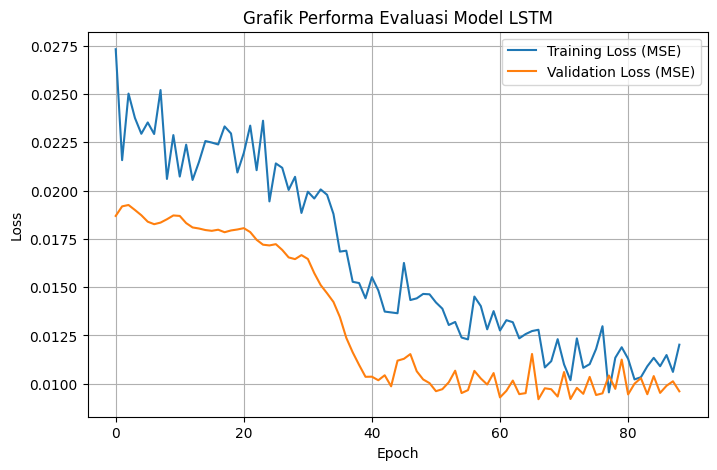

In [38]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss (MSE)")
plt.plot(history.history["val_loss"], label="Validation Loss (MSE)")
plt.title("Grafik Performa Evaluasi Model LSTM")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.grid(True)
plt.show()

### Grafik metrik selama training

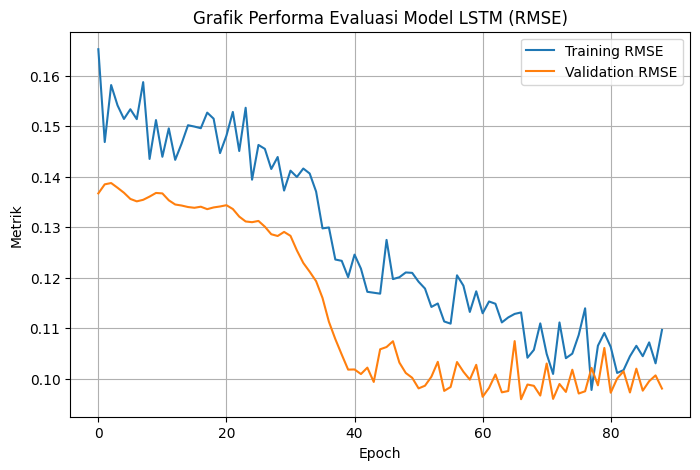

In [39]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["root_mean_squared_error"], label="Training RMSE")
plt.plot(history.history["val_root_mean_squared_error"], label="Validation RMSE")
plt.title("Grafik Performa Evaluasi Model LSTM (RMSE)")
plt.ylabel("Metrik")
plt.xlabel("Epoch")
plt.legend()
plt.grid(True)
plt.show()

### Hasil tebakan di data testing

Visualisasi Prediksi Model pada Data Testing:


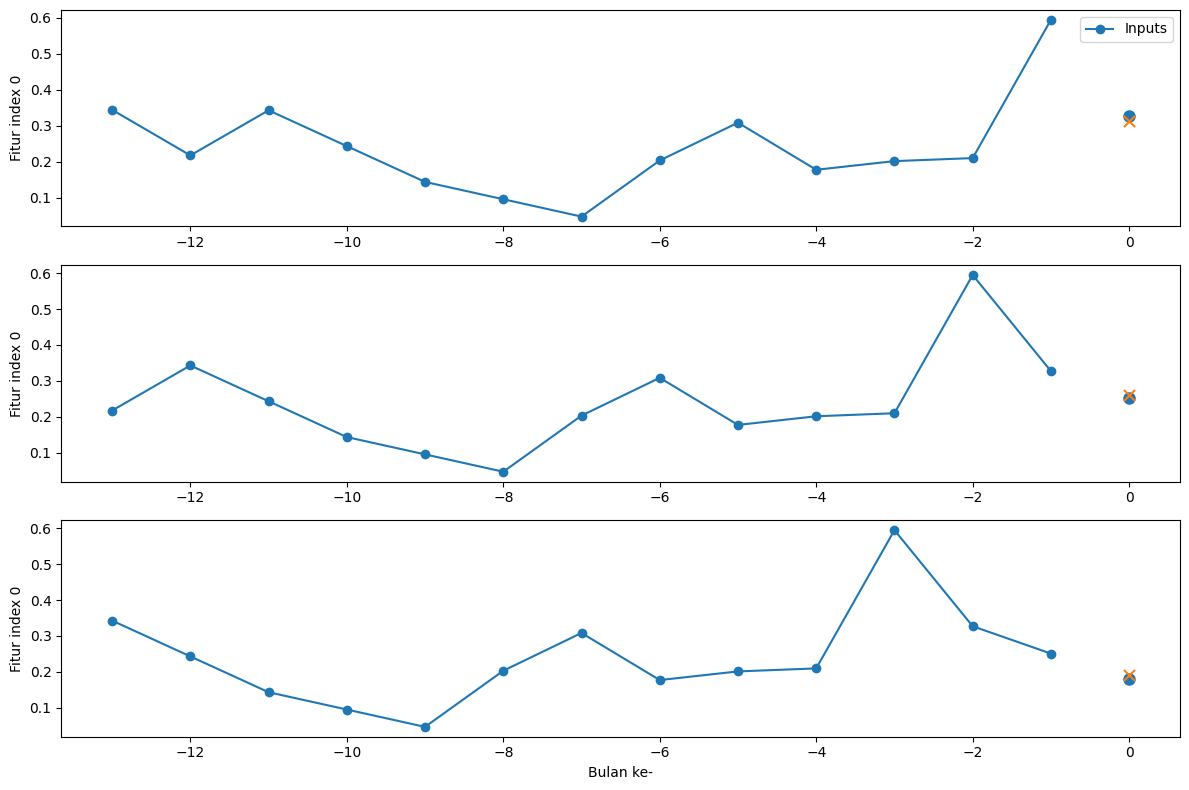

In [40]:
print("Visualisasi Prediksi Model pada Data Testing:")
test_window.plot(model=lstm_model, plot_col=0)

### Perbandingan hasil prediksi dan data asli

In [41]:
# Prediksi seluruh data testing
prediksi_hujan_scaled = lstm_model.predict(X_test)

# Menyiapkan dummy
dummy_prediksi = np.zeros((len(prediksi_hujan_scaled), X_train.shape[-1]))
dummy_aktual = np.zeros((len(y_test), X_train.shape[-1]))

# Memasukkan data prediksi dan aktual ke kolom curah hujan
dummy_prediksi[:, 0] = prediksi_hujan_scaled.flatten()
dummy_aktual[:, 0] = y_test.flatten()

# Melakukan inverse transform untuk kembali ke nilai satuan mm
prediksi_hujan = scaler.inverse_transform(dummy_prediksi)[:, 0]
aktual_hujan = scaler.inverse_transform(dummy_aktual)[:, 0]

# Menampilkan 5 hasil pertama
print("Perbandingan Curah Hujan (mm)")
for i in range(5):
    print(f"Hari ke-{i+1} | Aktual: {aktual_hujan[i]:.2f} mm | Prediksi: {prediksi_hujan[i]:.2f} mm")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Perbandingan Curah Hujan (mm)
Hari ke-1 | Aktual: 192.55 mm | Prediksi: 184.22 mm
Hari ke-2 | Aktual: 147.74 mm | Prediksi: 152.72 mm
Hari ke-3 | Aktual: 106.60 mm | Prediksi: 112.11 mm
Hari ke-4 | Aktual: 91.30 mm | Prediksi: 101.33 mm
Hari ke-5 | Aktual: 4.00 mm | Prediksi: 91.87 mm


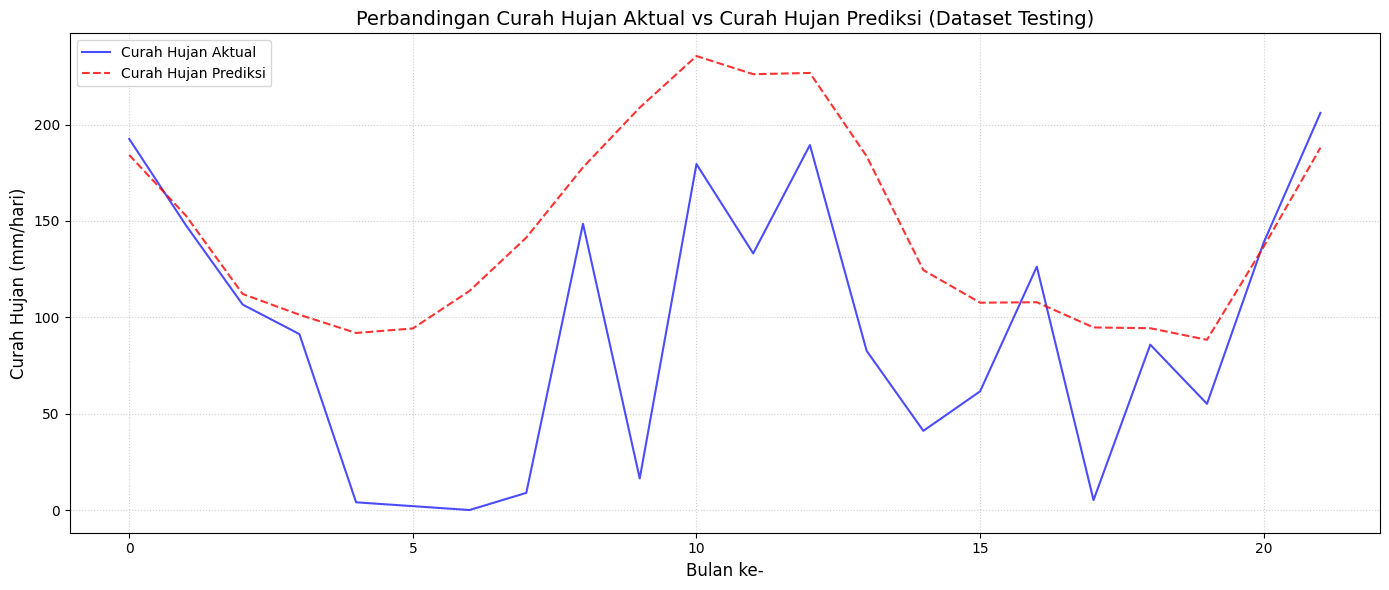

In [42]:
plt.figure(figsize=(14, 6))
plt.plot(aktual_hujan, label="Curah Hujan Aktual", color="blue", alpha=0.7)
plt.plot(prediksi_hujan, label="Curah Hujan Prediksi", color="red", linestyle="--", alpha=0.8)
plt.title("Perbandingan Curah Hujan Aktual vs Curah Hujan Prediksi (Dataset Testing)", fontsize=14)
plt.xlabel("Bulan ke-", fontsize=12)
plt.ylabel("Curah Hujan (mm/hari)", fontsize=12)
plt.legend(loc="upper left")
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [43]:
# Cek akurasi

mse_testing = mean_squared_error(aktual_hujan, prediksi_hujan)
rmse_testing = np.sqrt(mse_testing)
mape_testing = mean_absolute_percentage_error(aktual_hujan, prediksi_hujan) * 100
r2_testing = r2_score(aktual_hujan, prediksi_hujan)

print(f"mse: {mse_testing}")
print(f"rmse: {rmse_testing}")
print(f"mape: {mape_testing}")
print(f"r2 score: {r2_testing}")

mse: 5778.762130496375
rmse: 76.01816973919048
mape: 2.327936030216608e+18
r2 score: -0.25471699497002676


#### Lihat data train

In [44]:
# Prediksi seluruh data testing
prediksi_hujan_scaled_train = lstm_model.predict(X_train)

# Menyiapkan dummy
dummy_prediksi_train = np.zeros((len(prediksi_hujan_scaled_train), X_train.shape[-1]))
dummy_aktual_train = np.zeros((len(y_train), X_train.shape[-1]))

# Memasukkan data prediksi dan aktual ke kolom curah hujan
dummy_prediksi_train[:, 0] = prediksi_hujan_scaled_train.flatten()
dummy_aktual_train[:, 0] = y_train.flatten()

# Melakukan inverse transform untuk kembali ke nilai satuan mm
prediksi_hujan_train = scaler.inverse_transform(dummy_prediksi_train)[:, 0]
aktual_hujan_train = scaler.inverse_transform(dummy_aktual_train)[:, 0]

# Menampilkan 5 hasil pertama
print("Perbandingan Curah Hujan (mm)")
for i in range(5):
    print(f"Hari ke-{i+1} | Aktual: {aktual_hujan_train[i]:.2f} mm | Prediksi: {prediksi_hujan_train[i]:.2f} mm")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Perbandingan Curah Hujan (mm)
Hari ke-1 | Aktual: 324.62 mm | Prediksi: 216.85 mm
Hari ke-2 | Aktual: 156.87 mm | Prediksi: 185.86 mm
Hari ke-3 | Aktual: 75.68 mm | Prediksi: 147.47 mm
Hari ke-4 | Aktual: 154.54 mm | Prediksi: 111.29 mm
Hari ke-5 | Aktual: 94.69 mm | Prediksi: 84.78 mm


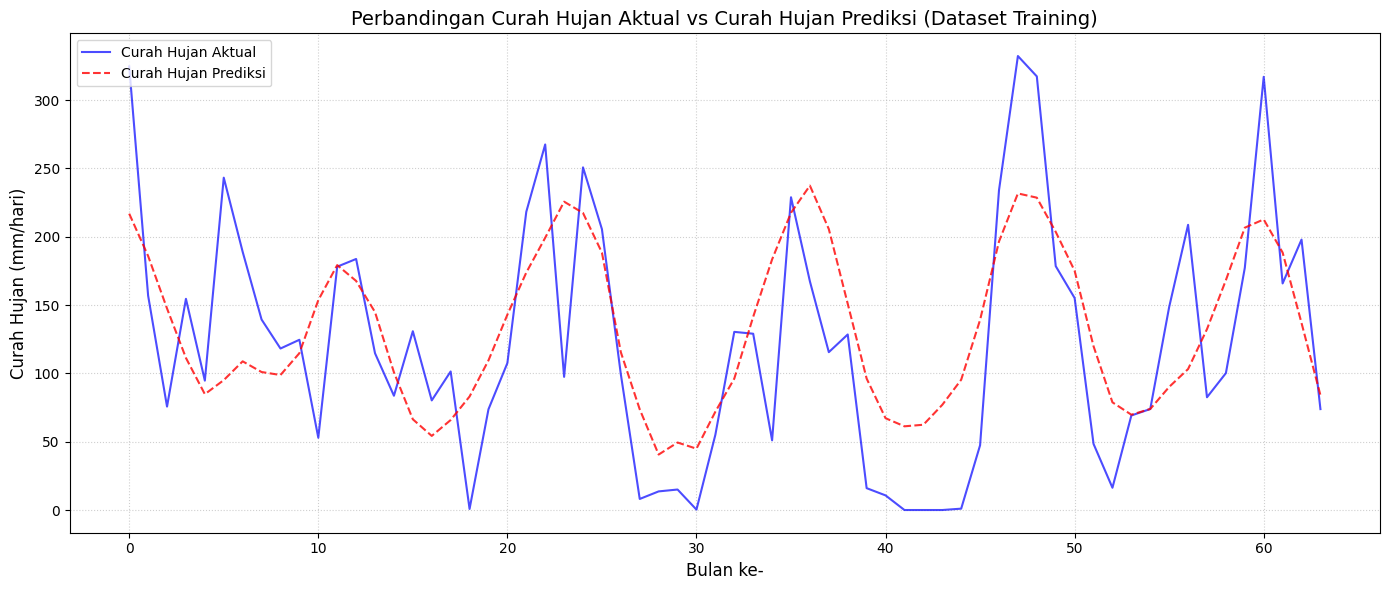

In [45]:
plt.figure(figsize=(14, 6))
plt.plot(aktual_hujan_train, label="Curah Hujan Aktual", color="blue", alpha=0.7)
plt.plot(prediksi_hujan_train, label="Curah Hujan Prediksi", color="red", linestyle="--", alpha=0.8)
plt.title("Perbandingan Curah Hujan Aktual vs Curah Hujan Prediksi (Dataset Training)", fontsize=14)
plt.xlabel("Bulan ke-", fontsize=12)
plt.ylabel("Curah Hujan (mm/hari)", fontsize=12)
plt.legend(loc="upper left")
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [46]:
# Cek akurasi

mse_training = mean_squared_error(aktual_hujan_train, prediksi_hujan_train)
rmse_training = np.sqrt(mse_training)
mape_training = mean_absolute_percentage_error(aktual_hujan_train, prediksi_hujan_train) * 100
r2_training = r2_score(aktual_hujan_train, prediksi_hujan_train)

print(f"mse: {mse_training}")
print(f"rmse: {rmse_training}")
print(f"mape: {mape_training}")
print(f"r2 score: {r2_training}")

mse: 3910.8931308454903
rmse: 62.53713401528319
mape: 1.4117067014581711e+18
r2 score: 0.4976675722061956


#### Lihat data validasi

In [47]:
# Prediksi seluruh data valid
prediksi_hujan_scaled_valid = lstm_model.predict(X_valid)

# Menyiapkan dummy
dummy_prediksi_valid = np.zeros((len(prediksi_hujan_scaled_valid), X_valid.shape[-1]))
dummy_aktual_valid = np.zeros((len(y_valid), X_valid.shape[-1]))

# Memasukkan data prediksi dan aktual ke kolom curah hujan
dummy_prediksi_valid[:, 0] = prediksi_hujan_scaled_valid.flatten()
dummy_aktual_valid[:, 0] = y_valid.flatten()

# Melakukan inverse transform untuk kembali ke nilai satuan mm
prediksi_hujan_valid = scaler.inverse_transform(dummy_prediksi_valid)[:, 0]
aktual_hujan_valid = scaler.inverse_transform(dummy_aktual_valid)[:, 0]

# Menampilkan 5 hasil pertama
print("Perbandingan Curah Hujan (mm)")
for i in range(5):
    print(f"Hari ke-{i+1} | Aktual: {aktual_hujan_valid[i]:.2f} mm | Prediksi: {prediksi_hujan_valid[i]:.2f} mm")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Perbandingan Curah Hujan (mm)
Hari ke-1 | Aktual: 85.43 mm | Prediksi: 51.81 mm
Hari ke-2 | Aktual: 23.94 mm | Prediksi: 43.73 mm
Hari ke-3 | Aktual: 69.49 mm | Prediksi: 50.68 mm
Hari ke-4 | Aktual: 77.75 mm | Prediksi: 65.16 mm
Hari ke-5 | Aktual: 119.95 mm | Prediksi: 97.30 mm


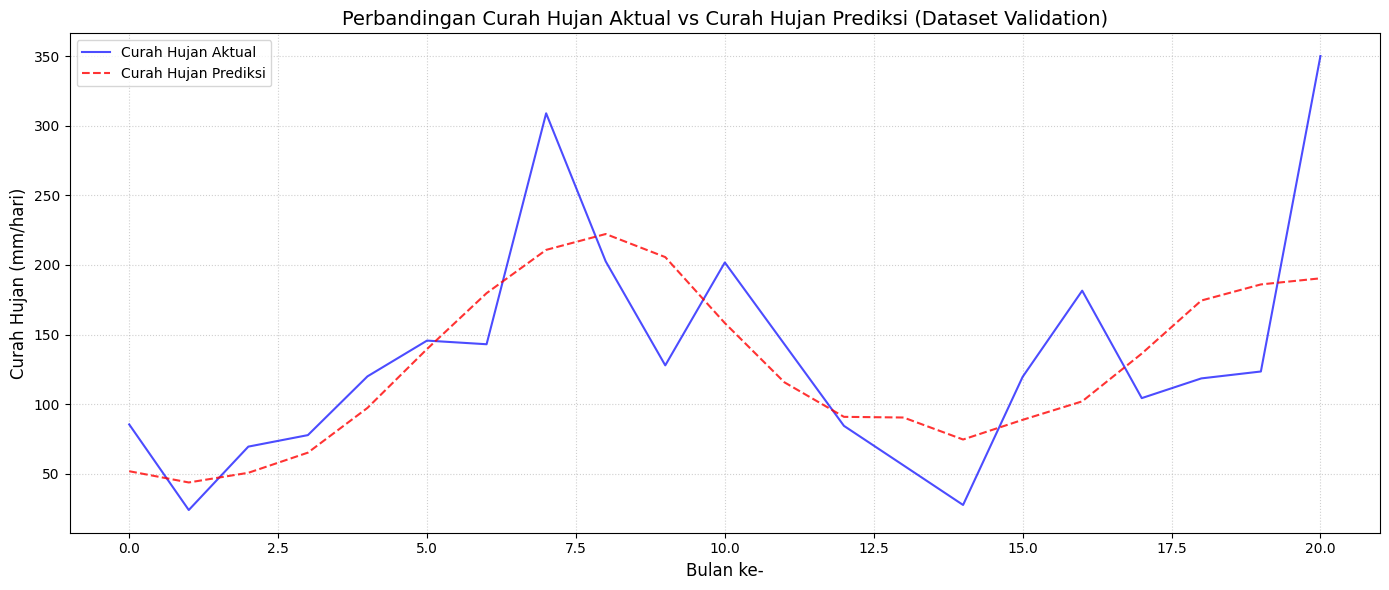

In [48]:
plt.figure(figsize=(14, 6))
plt.plot(aktual_hujan_valid, label="Curah Hujan Aktual", color="blue", alpha=0.7)
plt.plot(prediksi_hujan_valid, label="Curah Hujan Prediksi", color="red", linestyle="--", alpha=0.8)
plt.title("Perbandingan Curah Hujan Aktual vs Curah Hujan Prediksi (Dataset Validation)", fontsize=14)
plt.xlabel("Bulan ke-", fontsize=12)
plt.ylabel("Curah Hujan (mm/hari)", fontsize=12)
plt.legend(loc="upper left")
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [49]:
# Cek akurasi

mse_valid = mean_squared_error(aktual_hujan_valid, prediksi_hujan_valid)
rmse_valid = np.sqrt(mse_valid)
mape_valid = mean_absolute_percentage_error(aktual_hujan_valid, prediksi_hujan_valid) * 100
r2_valid = r2_score(aktual_hujan_valid, prediksi_hujan_valid)

print(f"mse: {mse_valid}")
print(f"rmse: {rmse_valid}")
print(f"mape: {mape_valid}")
print(f"r2 score: {r2_valid}")

mse: 3186.8136878687324
rmse: 56.45187054357661
mape: 40.021800116152704
r2 score: 0.49496457197712695


# Hasil Prediksi

In [50]:
def forecast_hujan(model, data_scaled, n_bulan, window_size):
    input = data_scaled[-window_size:].copy()
    prediksi = []

    for i in range(n_bulan):
        input_reshape = input[-window_size:].reshape(1, window_size, data_scaled.shape[1])

        prediksi_scaled = model.predict(input_reshape, verbose=1)
        prediksi_nilai = prediksi_scaled[0, 0]
        prediksi.append(prediksi_nilai)

        fitur_lain = data_scaled[-1,1:].copy()
        baris_baru = np.hstack([[prediksi_nilai], fitur_lain])
        input = np.vstack([input, baris_baru])

    return np.array(prediksi)

In [51]:
n_bulan_prediksi = 6
forecast_scaled = forecast_hujan(lstm_model, curah_hujan_scaled, n_bulan_prediksi, window_size)

dummy_forecast = np.zeros((len(forecast_scaled), len(fitur)))
dummy_forecast[:, 0] = forecast_scaled
forecast_final = scaler.inverse_transform(dummy_forecast)[:, 0]

print(f"--- HASIL PREDIKSI CURAH HUJAN {n_bulan_prediksi} BULAN KE DEPAN ---")
for i, hujan in enumerate(forecast_final):
    print(f"Bulan ke-{i + 1} | {hujan:.2f} mm")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
--- HASIL PREDIKSI CURAH HUJAN 6 BULAN KE DEPAN ---
Bulan ke-1 | 218.46 mm
Bulan ke-2 | 234.58 mm
Bulan ke-3 | 205.75 mm
Bulan ke-4 | 150.27 mm
Bulan ke-5 | 99.53 mm
Bulan ke-6 | 63.71 mm


In [52]:
forecast = pd.DataFrame(forecast_final, columns=["Prediksi Curah Hujan"])
forecast.to_csv("prediksi_curah_hujan_softplus(kaggle#2).csv", index=False)